messes with the accuracy but not always
for eg anamoly detectioon outliers importwnat 

dealing with it is imp 
linear logistics dl => outiers impact much 


how to deal 
trimming => thin ,fast
capping => limit isse jyada isse kaam outlier
missing value ke trah treat kena 
discretization => merge krndena nearby num se


how to determine outiers

normal distibution h toh  (mean +3*sigma )  to (mean - 3*sigma) ke andar cool 
skewed data => IQR  we use  min=Q1 - 1.5*IQR   max=Q3 + 1.5*IQR
percentile basesd approach => 99 percentile ke bahar outlier 5 ke andar outlier 

## Outlier removal using Z score

usesd for normal distribution 
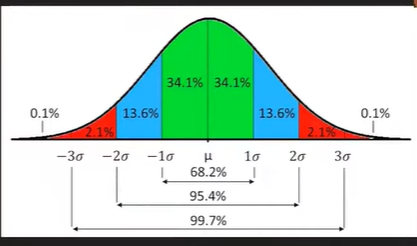

miu-3*std_dev miu+3*std_dev

Z_score
xi'=(xi - u)/sigma



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('placement.csv')

In [3]:
df.sample(5)

,Unnamed: 0,cgpa,iq,placement
80,80,4.9,196.0,0
28,28,5.2,90.0,0
48,48,6.6,138.0,1
45,45,6.0,66.0,1
94,94,4.7,52.0,0


In [4]:
df = df.drop(columns=['Unnamed: 0'])

In [5]:
df.sample(7)

,cgpa,iq,placement
83,7.5,130.0,1
62,6.0,102.0,0
49,5.4,135.0,0
31,3.9,109.0,0
97,6.7,182.0,1
34,4.8,163.0,0
50,3.5,233.0,0


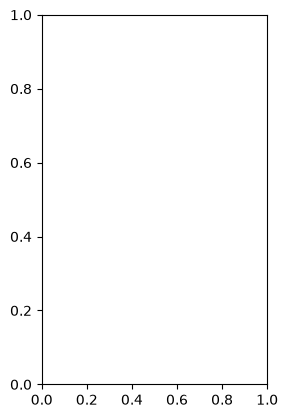

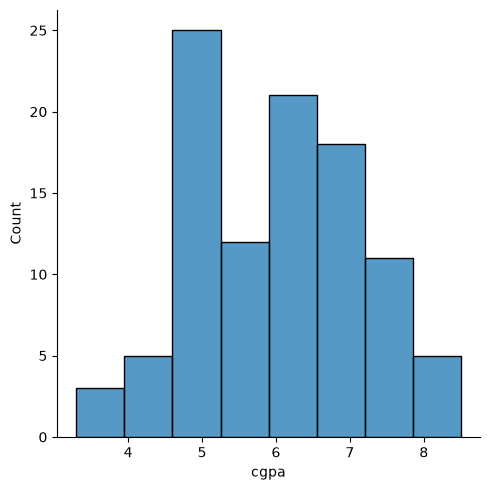

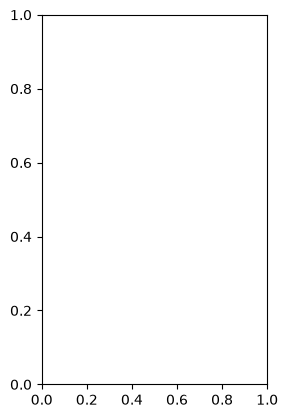

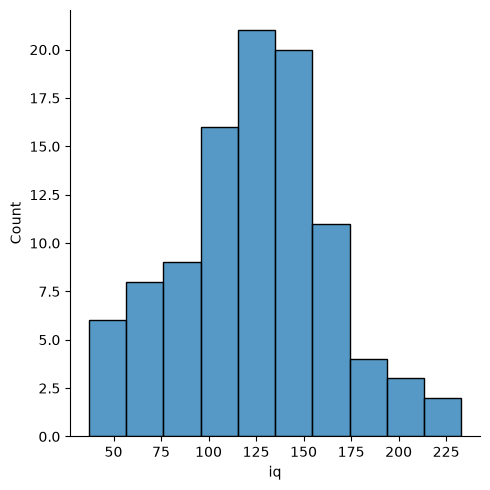

In [6]:
#plt.figure(figsize=(16,5))
#plt.subplot(1,2,1)
#sns.displot(df['cgpa'])

plt.subplot(1,2,1)
sns.displot(df['cgpa'])
plt.show()
plt.subplot(1,2,1)
sns.displot(df['iq'])
plt.show()

In [7]:
print("mean of cg" ,df['cgpa'].mean())
print("std dev" ,df['cgpa'].std())
print("min" ,df['cgpa'].min())
print("max" ,df['cgpa'].max())

mean of cg 5.9910000000000005
std dev 1.1436336737775692
min 3.3
max 8.5


In [8]:
#finding boundary values
print ("Highest allowed ",df['cgpa'].mean() + 3*df['cgpa'].std())
print ("Lowest allowed ",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed  9.421901021332708
Lowest allowed  2.560098978667293


In [9]:
#finding outliers
df[(df['cgpa']>9.42190) | (df['cgpa']<3)]

,cgpa,iq,placement


In [10]:
#surprisingly this datadset doesnt have outliers so lets tkae a random data
df[(df['cgpa']>9.789) | (df['cgpa']<5.11)]

,cgpa,iq,placement
7,5.0,63.0,0
9,5.1,66.0,0
15,5.1,176.0,0
17,3.3,183.0,0
18,4.0,100.0,0
22,4.9,120.0,0
23,4.7,87.0,0
24,4.7,121.0,0
25,5.0,91.0,0
31,3.9,109.0,0


now these kids are outliers we nee to remove them 
two ways for taht capping triming 

## Trimming

In [11]:
new_df=df[(df['cgpa']>9.789) | (df['cgpa']<5.11)]
new_df

,cgpa,iq,placement
7,5.0,63.0,0
9,5.1,66.0,0
15,5.1,176.0,0
17,3.3,183.0,0
18,4.0,100.0,0
22,4.9,120.0,0
23,4.7,87.0,0
24,4.7,121.0,0
25,5.0,91.0,0
31,3.9,109.0,0


In [12]:
df.shape

(100, 3)

In [13]:
new_df.shape

(28, 3)

In [14]:
# Aproach 2 
#calcualting Z-score
df['cgpa_zscore']= (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [15]:
df.head()

,cgpa,iq,placement,cgpa_zscore
0,6.8,123.0,1,0.707394
1,5.9,106.0,0,-0.079571
2,5.3,121.0,0,-0.604214
3,7.4,132.0,1,1.232038
4,5.8,142.0,0,-0.167012


In [16]:
df[df['cgpa_zscore']>2]
df[df['cgpa_zscore']<-2]

,cgpa,iq,placement,cgpa_zscore
17,3.3,183.0,0,-2.353026
50,3.5,233.0,0,-2.178145


In [17]:
#trimming

newdf= df[(df['cgpa_zscore']>2)  | (df['cgpa_zscore']<-2)]


In [18]:
newdf

,cgpa,iq,placement,cgpa_zscore
17,3.3,183.0,0,-2.353026
50,3.5,233.0,0,-2.178145
53,8.3,168.0,1,2.019003
69,8.5,120.0,1,2.193884


## Capping

In [19]:
upper_limit=df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit=df['cgpa'].mean() - 3*df['cgpa'].std()

In [20]:
df['cgpa']=np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [21]:
df.shape

(100, 4)

In [22]:
df['cgpa'].describe()

count    100.000000
mean       5.991000
std        1.143634
min        3.300000
25%        5.075000
50%        6.000000
75%        6.900000
max        8.500000
Name: cgpa, dtype: float64

## Outlier detection using IQR

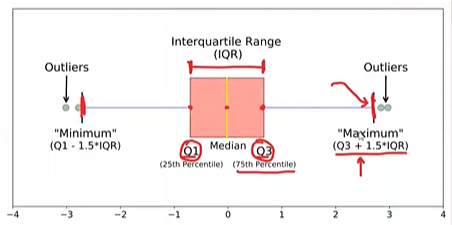


In [23]:
df.sample ()

,cgpa,iq,placement,cgpa_zscore
93,6.8,112.0,1,0.707394


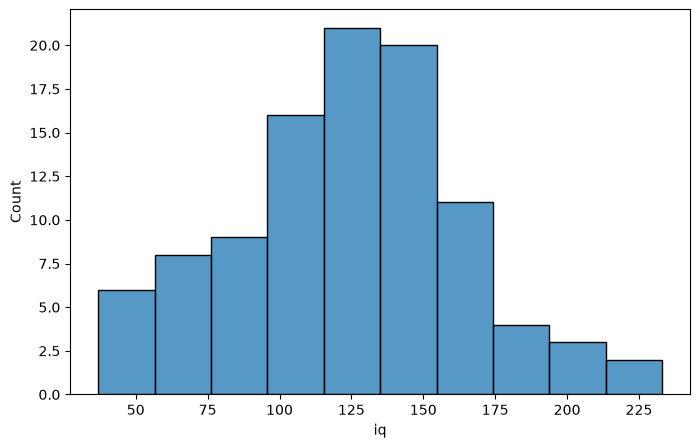

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    df['iq'],
    bins=10,
    kde=False
)

plt.xlabel('iq')
plt.ylabel('Count')
plt.show()

In [27]:
df['iq'].skew()

np.float64(0.018095580898964243)

In [28]:
df['iq'].describe()

count    100.000000
mean     123.580000
std       39.944198
min       37.000000
25%      101.500000
50%      127.500000
75%      149.000000
max      233.000000
Name: iq, dtype: float64

<Axes: ylabel='iq'>

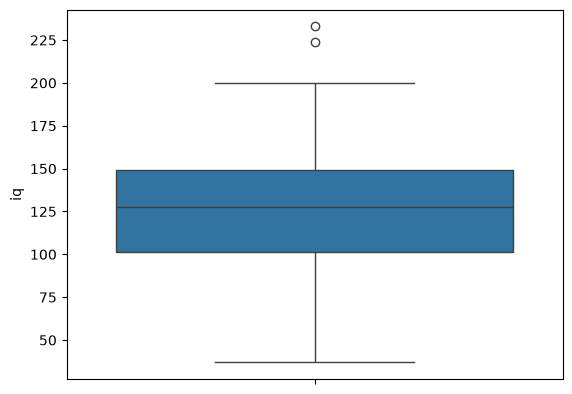

In [29]:
sns.boxplot(df['iq'])

In [30]:
# Finding IQR
percentile25=df['iq'].quantile(0.25)
percentile75=df['iq'].quantile(0.75)

In [32]:
iqr = percentile75-percentile25
iqr

np.float64(47.5)

In [33]:
up_limit = percentile75+1.5*iqr
low_limit=percentile25-1.5*iqr

In [34]:
print("UpperLimit",up_limit)
print("LowerLimit",low_limit)

UpperLimit 220.25
LowerLimit 30.25


### finding Outliers


In [37]:
df[(df['iq'] > low_limit) & (df['iq'] < up_limit)]

,cgpa,iq,placement,cgpa_zscore
0,6.8,123.0,1,0.707394
1,5.9,106.0,0,-0.079571
2,5.3,121.0,0,-0.604214
3,7.4,132.0,1,1.232038
4,5.8,142.0,0,-0.167012
...,...,...,...,...
95,4.3,200.0,0,-1.478620
96,4.4,42.0,0,-1.391180
97,6.7,182.0,1,0.619954
98,6.3,103.0,1,0.270191


### Trimming

In [40]:
new_df=df[(df['iq'] > low_limit) & (df['iq'] < up_limit)]
new_df.shape

(98, 4)

<Axes: ylabel='iq'>

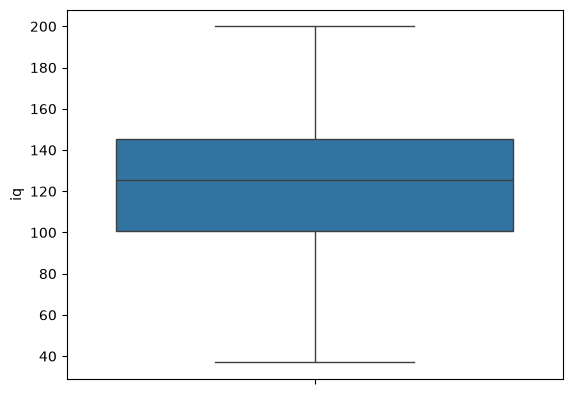

In [42]:
## comparing
sns.boxplot(new_df['iq'])

In [44]:
new_df_cap=df.copy()



new_df_cap['iq']=np.where(
    new_df_cap['iq']>upper_limit,
    upper_limit,
    np.where(
        new_df_cap['iq']<lower_limit,
        lower_limit,
        new_df_cap['iq']
    )
)

### Using %ile method

ek value decide uskeupar niche jo bhi h usko outliers declare


In [46]:
dff=pd.read_csv('weight-height.csv')
dff.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [47]:
df.shape

(100, 4)

In [50]:
dff['Height'].describe

<bound method NDFrame.describe of 0       73.847017
1       68.781904
2       74.110105
3       71.730978
4       69.881796
          ...    
9995    66.172652
9996    67.067155
9997    63.867992
9998    69.034243
9999    61.944246
Name: Height, Length: 10000, dtype: float64>

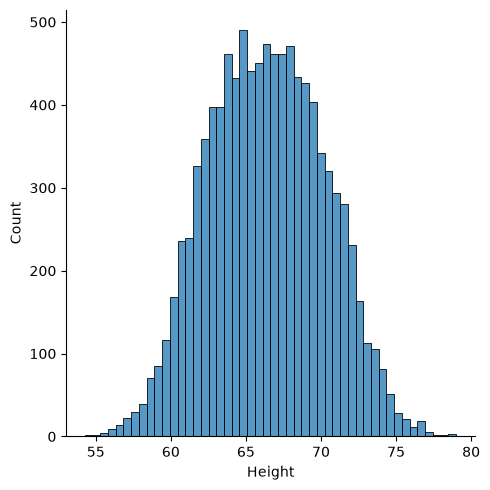

In [51]:
sns.displot(dff['Height'])

<Axes: ylabel='Height'>

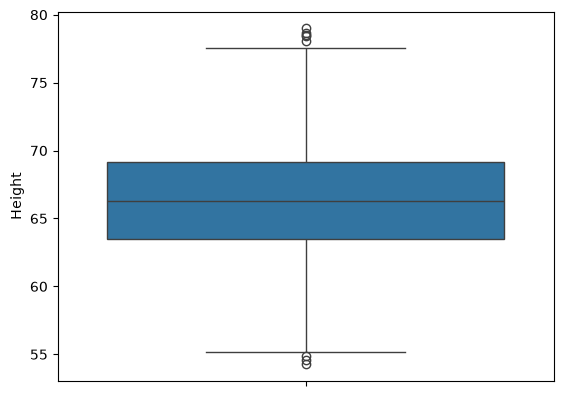

In [52]:
sns.boxplot(dff['Height'])

In [54]:
upp_limit=dff['Height'].quantile(0.99)
loww_limit=dff['Height'].quantile(0.01)
upp_limit

np.float64(74.7857900583366)

In [55]:
loww_limit

np.float64(58.13441158671655)

In [60]:
new_dff=dff[(dff['Height'] >= 58.13) & (dff['Height'] <= 74.78)]
new_dff

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [61]:
new_dff.describe()

,Height,Weight
count,9799.000000,9799.000000
mean,66.363507,161.391522
std,3.644267,30.925072
min,58.134496,77.523774
25%,63.577147,136.320936
50%,66.317899,161.201891
75%,69.119859,186.747036
max,74.767447,249.946283


In [62]:
dff.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


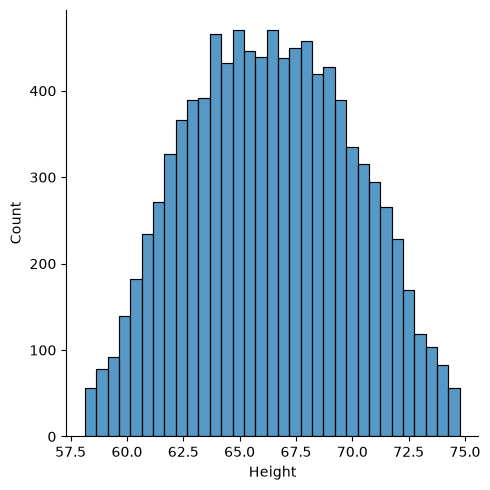

In [63]:
sns.displot(new_dff['Height'])

<Axes: ylabel='Height'>

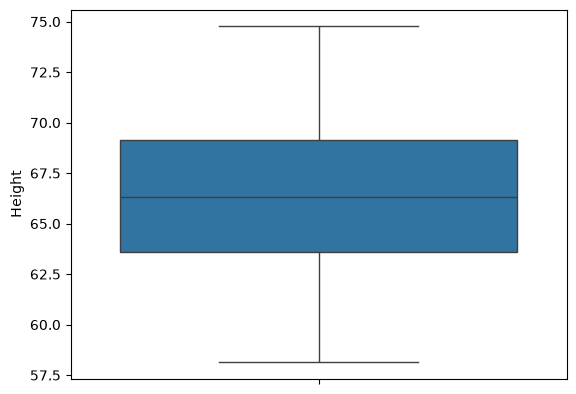

In [64]:
sns.boxplot(new_dff['Height'])

In [66]:
#Capping

np.where(new_dff['Height']>upp_limit,
    upper_limit,
    np.where(
        new_dff['Height']<loww_limit,
        loww_limit,
        new_dff['Height']
    )
)

array([73.84701702, 68.78190405, 74.11010539, ..., 63.86799221,
       69.03424313, 61.94424588], shape=(9799,))